this jupyter file will clean the CICIOT2023 dataset

for speed we randomly select 18 files of the all 169 file in this dataset
you could run all these code for all the files

In [1]:
#imports
import pandas as pd
import numpy as np
import random
import glob
import os

In [2]:
#load files
# Path to folder containing the 18 CSV files
folder_path = './ciciot-dataset-partial'
all_files = glob.glob(os.path.join(folder_path, "*.csv"))

# Randomly select 5 files from the list
selected_files = random.sample(all_files, 1)

print("Selected files:")
for f in selected_files:
    print(f)

# Read and concatenate ONLY the randomly selected csv files
df_list = [pd.read_csv(file) for file in selected_files]
df = pd.concat(df_list, ignore_index=True)

print(f"\nTotal rows: {df.shape[0]}, Total columns: {df.shape[1]}")


Selected files:
./ciciot-dataset-partial/part-00142-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv

Total rows: 260694, Total columns: 47


In [3]:
# Show the first few rows
display(df.head())

# Check for missing values (NaN)
print("\nMissing values per column:")
print(df.isnull().sum().max()) # Shows maximum missing values in any column

# Check data types 
print("\nData Types:")
print(df.dtypes.value_counts())


,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,0.068782,56.94,6.00,63.78,0.737876,0.737876,0.0,0.0,1.0,0.0,...,0.055884,54.04,8.308890e+07,9.5,10.393646,0.079335,0.052539,0.06,141.55,DDoS-SYN_Flood
1,0.000000,53.46,5.94,63.36,2.659408,2.659408,0.0,1.0,0.0,1.0,...,0.099279,54.06,8.334493e+07,9.5,10.394727,0.140855,0.142091,0.07,141.55,DDoS-RSTFINFlood
2,0.000000,54.00,6.00,64.00,506.711447,506.711447,0.0,0.0,1.0,0.0,...,0.000000,54.00,8.309019e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-SYN_Flood
3,0.000000,0.00,47.00,64.00,0.400142,0.400142,0.0,0.0,0.0,0.0,...,0.000000,578.00,8.365096e+07,9.5,34.000000,0.000000,0.000000,0.00,141.55,Mirai-greip_flood
4,0.000000,0.00,1.00,67.82,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.000000,42.00,8.312882e+07,9.5,9.165151,0.000000,0.000000,0.00,141.55,DDoS-ICMP_Flood



Missing values per column:
0

Data Types:
float64    46
str         1
Name: count, dtype: int64


### Cleaning Data

In [4]:
from sklearn.preprocessing import LabelEncoder

# 1. Replace Infinite values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# 2. Drop rows with missing values (NaN)
for col in df.columns:
    if col != 'label':
        df[col] = pd.to_numeric(df[col], errors='coerce')

df.dropna(inplace=True)

# 3. Encode the target 'label' column to numbers
label_col = 'label' 

encoder = LabelEncoder()
df[label_col] = encoder.fit_transform(df[label_col])


In [6]:
# Show the cleaned data
display(df.head())

# Verify no missing or infinite values exist
print("\nTotal missing values left:", df.isnull().sum().sum())
print("Are there any infinite values left?", np.isinf(df.drop(columns=[label_col])).sum().sum() > 0)

# Verify all columns are now numeric (suitable for ML models)
print("\nCleaned Data Types:")
print(df.dtypes.value_counts())

# Show the mapping of our encoded labels
print("\nLabel Encoding Mapping:")
label_mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
print(label_mapping)


,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,0.000000,54.0,6.0,64.0,26.489058,26.489058,0.0,1.0,0.0,1.0,...,0.000000,54.0,8.334429e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,9
1,4.223779,108.0,6.0,64.0,0.473510,0.473510,0.0,0.0,1.0,0.0,...,0.000000,54.0,8.298533e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,19
2,0.016861,579.6,6.0,64.0,42.712086,42.712086,0.0,0.0,0.0,0.0,...,540.959663,694.8,8.334010e+07,9.5,34.502087,765.515748,320034.518098,0.93,141.55,4
3,0.000000,0.0,1.0,64.0,1.523349,1.523349,0.0,0.0,0.0,0.0,...,0.000000,42.0,8.314968e+07,9.5,9.165151,0.000000,0.000000,0.00,141.55,6
4,0.172906,564.5,8.2,63.2,35.688327,35.688327,0.0,0.0,0.0,0.0,...,86.386189,132.6,1.665164e+08,13.5,14.755254,122.467486,7902.995575,1.00,244.60,1



Total missing values left: 0
Are there any infinite values left? False

Cleaned Data Types:
float64    46
int64       1
Name: count, dtype: int64

Label Encoding Mapping:
{'Backdoor_Malware': np.int64(0), 'BenignTraffic': np.int64(1), 'BrowserHijacking': np.int64(2), 'CommandInjection': np.int64(3), 'DDoS-ACK_Fragmentation': np.int64(4), 'DDoS-HTTP_Flood': np.int64(5), 'DDoS-ICMP_Flood': np.int64(6), 'DDoS-ICMP_Fragmentation': np.int64(7), 'DDoS-PSHACK_Flood': np.int64(8), 'DDoS-RSTFINFlood': np.int64(9), 'DDoS-SYN_Flood': np.int64(10), 'DDoS-SlowLoris': np.int64(11), 'DDoS-SynonymousIP_Flood': np.int64(12), 'DDoS-TCP_Flood': np.int64(13), 'DDoS-UDP_Flood': np.int64(14), 'DDoS-UDP_Fragmentation': np.int64(15), 'DNS_Spoofing': np.int64(16), 'DictionaryBruteForce': np.int64(17), 'DoS-HTTP_Flood': np.int64(18), 'DoS-SYN_Flood': np.int64(19), 'DoS-TCP_Flood': np.int64(20), 'DoS-UDP_Flood': np.int64(21), 'MITM-ArpSpoofing': np.int64(22), 'Mirai-greeth_flood': np.int64(23), 'Mirai-greip_flo

### Train/Test split

In [5]:
from sklearn.model_selection import train_test_split

# Define target column
target_col = 'label'

# Separate features and target
X = df.drop(columns=[target_col])
y = df[target_col]

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Optional: combine for easy inspection
train_df = X_train.copy()
train_df[target_col] = y_train

test_df = X_test.copy()
test_df[target_col] = y_test

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain label distribution:")
print(y_train.value_counts())

print("\nTest label distribution:")
print(y_test.value_counts())


Train shape: (208555, 47)
Test shape: (52139, 47)

Train label distribution:
label
6     32259
14    24018
13    19938
8     18366
10    18146
9     18026
12    16006
21    14977
20    12062
19     9087
1      4900
23     4438
25     4082
24     3290
7      2006
22     1331
15     1292
4      1246
16      777
26      582
27      438
29      354
18      346
32      170
5       128
11       98
17       73
3        30
30       26
2        22
28       14
33       11
0        10
31        6
Name: count, dtype: int64

Test label distribution:
label
6     8065
14    6005
13    4984
8     4592
10    4537
9     4507
12    4002
21    3744
20    3015
19    2272
1     1225
23    1109
25    1020
24     822
7      501
22     333
15     323
4      311
16     194
26     146
27     109
29      88
18      86
32      42
5       32
11      24
17      18
3        8
30       7
2        6
28       4
33       3
0        3
31       2
Name: count, dtype: int64


### feature scaling

In [6]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Initialize scaler
scaler = StandardScaler()

# Fit only on training data, then transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# Re-attach labels
df_train_scaled = X_train_scaled.copy()
df_train_scaled['label'] = y_train

df_test_scaled = X_test_scaled.copy()
df_test_scaled['label'] = y_test

# Display scaled training data
df_train_scaled.head()


,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
21926,-0.020543,-0.166566,-0.902478,-0.166723,-0.091686,-0.091686,-0.00307,-0.307457,-0.511453,-0.314918,...,-0.209058,-0.343964,0.000383,0.005361,-0.459334,-0.208887,-0.104262,-0.413359,0.005368,6
240573,-0.020478,-0.138454,0.890664,-0.166723,0.039222,0.039222,-0.00307,-0.307457,-0.511453,-0.314918,...,-0.209058,-0.310676,-0.001400,0.005361,-0.362488,-0.208887,-0.104262,-0.413359,0.005368,14
142460,-0.019819,-0.131822,0.890664,-0.166723,0.025173,0.025173,-0.00307,-0.307457,-0.511453,-0.314918,...,-0.209058,-0.310676,-0.001442,0.005361,-0.362488,-0.208887,-0.104262,-0.413359,0.005368,14
231448,0.010921,-0.166182,-0.329793,-0.120749,-0.091915,-0.091915,-0.00307,-0.307457,1.955214,-0.314918,...,-0.192530,-0.265820,-0.008800,0.005361,-0.266785,-0.192265,-0.103662,-0.241046,0.005368,19
230326,-0.001652,-0.166328,-0.329793,-0.120749,-0.091914,-0.091914,-0.00307,-0.307457,-0.511453,-0.314918,...,-0.200967,-0.292741,-0.010096,0.005361,-0.312486,-0.200785,-0.104223,0.232815,0.005368,20


### balancing data

/tmp/ipykernel_6921/354416753.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="tab10")


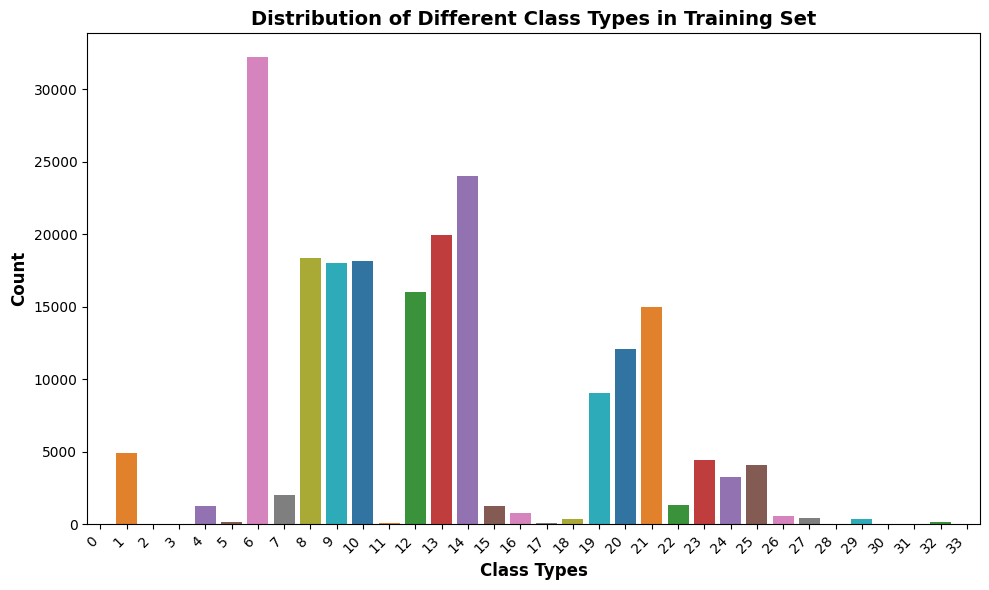

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the occurrences of each class in the training label column
class_counts = df_train_scaled['label'].value_counts().sort_index()

# Set up the figure size
plt.figure(figsize=(10, 6))

# Create the bar plot
sns.barplot(x=class_counts.index, y=class_counts.values, palette="tab10")

# Add titles and labels
plt.title('Distribution of Different Class Types in Training Set', fontsize=14, fontweight='bold')
plt.xlabel('Class Types', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')

# Rotate the x-axis labels
plt.xticks(rotation=45, ha='right')

# Adjust layout
plt.tight_layout()

# Display the plot
plt.show()


/tmp/ipykernel_6921/1262264803.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=category_counts.index, y=category_counts.values, palette="tab10")


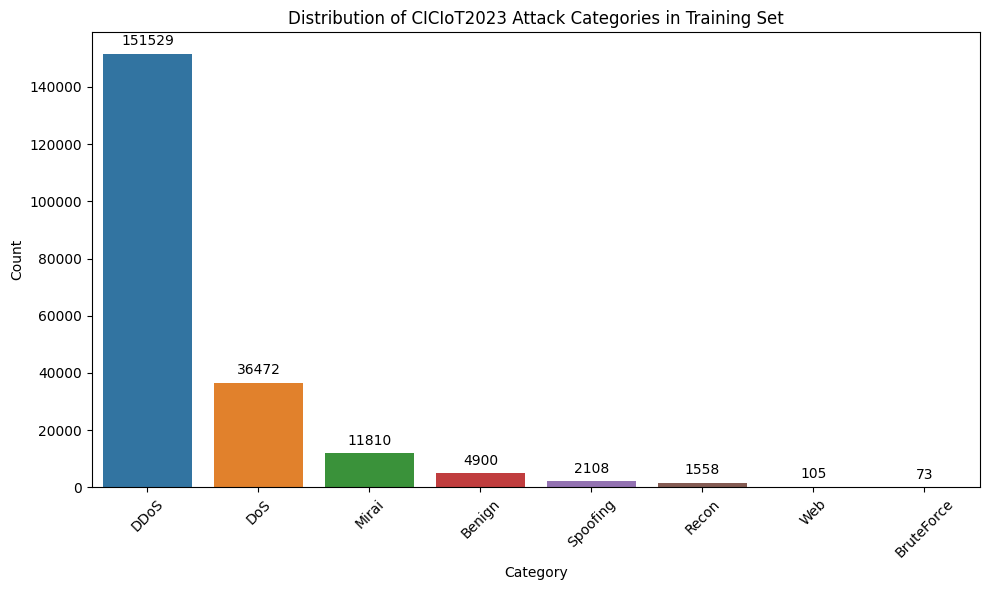

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Define the dictionary to map the 34 sub-classes to the 8 main categories
attack_mapping = {
    'BenignTraffic': 'Benign',
    
    'DDoS-ICMP_Flood': 'DDoS', 'DDoS-UDP_Flood': 'DDoS', 'DDoS-TCP_Flood': 'DDoS',
    'DDoS-PSHACK_Flood': 'DDoS', 'DDoS-SYN_Flood': 'DDoS', 'DDoS-RSTFINFlood': 'DDoS',
    'DDoS-SynonymousIP_Flood': 'DDoS', 'DDoS-ICMP_Fragmentation': 'DDoS', 
    'DDoS-UDP_Fragmentation': 'DDoS', 'DDoS-ACK_Fragmentation': 'DDoS', 
    'DDoS-HTTP_Flood': 'DDoS', 'DDoS-SlowLoris': 'DDoS',
    
    'DoS-UDP_Flood': 'DoS', 'DoS-TCP_Flood': 'DoS', 'DoS-SYN_Flood': 'DoS', 'DoS-HTTP_Flood': 'DoS',
    
    'Recon-HostDiscovery': 'Recon', 'Recon-OSScan': 'Recon', 'Recon-PortScan': 'Recon',
    'Recon-PingSweep': 'Recon', 'VulnerabilityScan': 'Recon',
    
    'Mirai-greeth_flood': 'Mirai', 'Mirai-greip_flood': 'Mirai', 'Mirai-udpplain': 'Mirai',
    
    'MITM-ArpSpoofing': 'Spoofing', 'DNS_Spoofing': 'Spoofing',
    
    'DictionaryBruteForce': 'BruteForce',
    
    'BrowserHijacking': 'Web', 'SqlInjection': 'Web', 'CommandInjection': 'Web', 
    'Backdoor_Malware': 'Web', 'XSS': 'Web', 'Uploading_Attack': 'Web'
}


# Work on a copy of training dataframe
df_train_mapped = df_train_scaled.copy()

# Reverse label encoding to original class names
if pd.api.types.is_numeric_dtype(df_train_mapped['label']):
    df_train_mapped['label_string'] = encoder.inverse_transform(df_train_mapped['label'].astype(int))
else:
    df_train_mapped['label_string'] = df_train_mapped['label']

# Map to 8 parent categories
df_train_mapped['category'] = df_train_mapped['label_string'].map(attack_mapping)

# Count category distribution
category_counts = df_train_mapped['category'].value_counts()

# Plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=category_counts.index, y=category_counts.values, palette="tab10")

# Add numbers on bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.title('Distribution of CICIoT2023 Attack Categories in Training Set')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Benign count: 4900
Each attack class will be balanced to: 700

Final distribution after precise balancing:
category
Benign        4900
BruteForce     700
DDoS           700
DoS            700
Mirai          700
Recon          700
Spoofing       700
Web            700
Name: count, dtype: int64


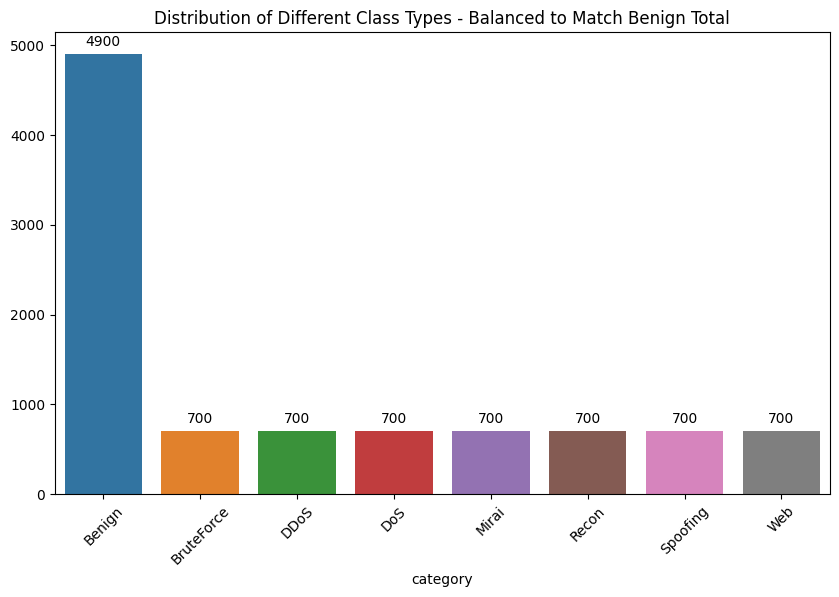

In [22]:
# # from imblearn.over_sampling import SMOTE
# # import matplotlib.pyplot as plt
# # import seaborn as sns
# # import pandas as pd

# # # 1. Check for unmapped labels
# # unmapped_labels = df_train_mapped[df_train_mapped['category'].isna()]['label_string'].unique()
# # if len(unmapped_labels) > 0:
# #     print(f"Warning: Found unmapped labels which became NaN: {unmapped_labels}")
# #     print("Dropping these rows before applying SMOTE...")

# # # Drop rows with missing category
# # df_clean_for_smote = df_train_mapped.dropna(subset=['category']).copy()

# # # 2. Separate features and 8-category target
# # X_train_for_smote = df_clean_for_smote.drop(columns=['label', 'label_string', 'category'], errors='ignore')
# # y_train_for_smote = df_clean_for_smote['category']

# # # 3. Apply SMOTE ONLY on training data
# # print("Applying SMOTE on training data... (This might take a while)")
# # smote = SMOTE(random_state=42)
# # X_train_resampled, y_train_resampled = smote.fit_resample(X_train_for_smote, y_train_for_smote)

# # # 4. Combine back into a DataFrame
# # df_train_balanced = pd.DataFrame(X_train_resampled, columns=X_train_for_smote.columns)
# # df_train_balanced['category'] = y_train_resampled

# # # 5. Count occurrences after balancing
# # category_counts_balanced = df_train_balanced['category'].value_counts()
# # print("\nClass Distribution after SMOTE (Training Set):")
# # print(category_counts_balanced)

# # # 6. Plot balanced distribution
# # plt.figure(figsize=(10, 6))
# # ax = sns.barplot(x=category_counts_balanced.index, y=category_counts_balanced.values, palette="tab10")

# # # Add exact numbers on top of each bar
# # for p in ax.patches:
# #     ax.annotate(format(p.get_height(), '.0f'),
# #                 (p.get_x() + p.get_width() / 2., p.get_height()),
# #                 ha='center', va='center',
# #                 xytext=(0, 9),
# #                 textcoords='offset points')

# # plt.title('Distribution of CICIoT2023 Attack Categories in Training Set (After SMOTE)')
# # plt.xlabel('Category')
# # plt.ylabel('Count')
# # plt.xticks(rotation=45)
# # plt.tight_layout()
# # plt.show()



# from imblearn.over_sampling import SMOTE
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Remove rows with missing category if any
# df_clean_for_smote = df_train_mapped.dropna(subset=['category']).copy()

# # Separate features and target
# X_train_for_smote = df_clean_for_smote.drop(columns=['label', 'label_string', 'category'], errors='ignore')
# y_train_for_smote = df_clean_for_smote['category']

# # Count original class distribution
# original_counts = y_train_for_smote.value_counts()
# print("Original 8-class distribution:")
# print(original_counts)

# # Benign count
# benign_count = original_counts['Benign']

# # Target count for each attack class so that:
# # sum(all 7 attacks) = benign_count
# target_attack_count = benign_count // 7

# print(f"\nBenign count: {benign_count}")
# print(f"Target count for each attack class: {target_attack_count}")

# # Build custom sampling strategy
# sampling_strategy_custom = {}

# for cls, count in original_counts.items():
#     if cls == 'Benign':
#         continue
#     # Only oversample if class is smaller than target
#     if count < target_attack_count:
#         sampling_strategy_custom[cls] = target_attack_count
#     else:
#         sampling_strategy_custom[cls] = count

# print("\nCustom sampling strategy:")
# print(sampling_strategy_custom)

# # Apply custom SMOTE
# smote_custom = SMOTE(
#     sampling_strategy=sampling_strategy_custom,
#     random_state=42
# )

# X_train_resampled_custom, y_train_resampled_custom = smote_custom.fit_resample(
#     X_train_for_smote,
#     y_train_for_smote
# )

# # Combine back
# df_train_balanced_custom = pd.DataFrame(X_train_resampled_custom, columns=X_train_for_smote.columns)
# df_train_balanced_custom['category'] = y_train_resampled_custom

# # Counts after custom SMOTE
# category_counts_balanced_custom = df_train_balanced_custom['category'].value_counts()
# print("\n8-class distribution after custom SMOTE:")
# print(category_counts_balanced_custom)

# # Plot
# plt.figure(figsize=(10, 6))
# ax = sns.barplot(
#     x=category_counts_balanced_custom.index,
#     y=category_counts_balanced_custom.values,
#     hue=category_counts_balanced_custom.index,
#     palette="tab10",
#     legend=False
# )

# for p in ax.patches:
#     ax.annotate(format(p.get_height(), '.0f'),
#                 (p.get_x() + p.get_width() / 2., p.get_height()),
#                 ha='center', va='center',
#                 xytext=(0, 9),
#                 textcoords='offset points')

# plt.title('Distribution of Different Class Types - After application of SMOTE technique')
# plt.xlabel('Class Type')
# plt.ylabel('Count')
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()


from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. محاسبه مقدار هدف
original_counts = y_train_for_smote.value_counts()
benign_count = original_counts['Benign']
target_val = benign_count // 7  # مقدار هر کلاس حمله برای برابری با مجموع Benign

print(f"Benign count: {benign_count}")
print(f"Each attack class will be balanced to: {target_val}")

# 2. تفکیک کلاس‌ها برای Over و Under
over_strategy = {}
under_strategy = {}

for cls, count in original_counts.items():
    if cls == 'Benign':
        continue
    if count < target_val:
        # اگر کمتر است، باید زیاد شود (SMOTE)
        over_strategy[cls] = target_val
    elif count > target_val:
        # اگر بیشتر است، باید کم شود (UnderSampler)
        under_strategy[cls] = target_val

# 3. مرحله اول: افزایش کلاس‌های کوچک (SMOTE)
# فقط کلاس‌هایی که نیاز به افزایش دارند در over_strategy هستند
if over_strategy:
    smote = SMOTE(sampling_strategy=over_strategy, random_state=42)
    X_over, y_over = smote.fit_resample(X_train_for_smote, y_train_for_smote)
else:
    X_over, y_over = X_train_for_smote, y_train_for_smote

# 4. مرحله دوم: کاهش کلاس‌های بزرگ (UnderSampler)
# حالا همه کلاس‌های حمله یا target_val هستند یا بیشتر. با این کار همه را دقیقاً مساوی می‌کنیم.
under = RandomUnderSampler(sampling_strategy=under_strategy, random_state=42)
X_final, y_final = under.fit_resample(X_over, y_over)

# 5. ساخت دیتافریم نهایی
df_train_balanced_final = pd.DataFrame(X_final, columns=X_train_for_smote.columns)
df_train_balanced_final['category'] = y_final

print("\nFinal distribution after precise balancing:")
print(df_train_balanced_final['category'].value_counts())

# 6. رسم نمودار (دقیقاً مشابه تصویر درخواستی شما)
plt.figure(figsize=(10, 6))
final_counts = df_train_balanced_final['category'].value_counts()
ax = sns.barplot(x=final_counts.index, y=final_counts.values, hue=final_counts.index, palette="tab10", legend=False)

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.title('Distribution of Different Class Types - Balanced to Match Benign Total')
plt.xticks(rotation=45)
plt.show()


### binary labaling

In [25]:
import pandas as pd

# Make copies
df_train_binary = df_train_mapped.copy()
df_test_binary = df_test_scaled.copy()

# Recover original label strings for test set too
if pd.api.types.is_numeric_dtype(df_test_binary['label']):
    df_test_binary['label_string'] = encoder.inverse_transform(df_test_binary['label'].astype(int))
else:
    df_test_binary['label_string'] = df_test_binary['label']

# Create binary labels: Benign=0, Attack=1
df_train_binary['binary_label'] = df_train_binary['label_string'].apply(
    lambda x: 0 if x == 'BenignTraffic' else 1
)

df_test_binary['binary_label'] = df_test_binary['label_string'].apply(
    lambda x: 0 if x == 'BenignTraffic' else 1
)

print("Train binary label distribution:")
print(df_train_binary['binary_label'].value_counts())

print("\nTest binary label distribution:")
print(df_test_binary['binary_label'].value_counts())


Train binary label distribution:
binary_label
1    203655
0      4900
Name: count, dtype: int64

Test binary label distribution:
binary_label
1    50914
0     1225
Name: count, dtype: int64


In [27]:
import pandas as pd

# BEFORE BALANCING
df_train_binary = df_train_mapped.copy()
df_test_binary = df_test_scaled.copy()

if pd.api.types.is_numeric_dtype(df_test_binary['label']):
    df_test_binary['label_string'] = encoder.inverse_transform(df_test_binary['label'].astype(int))
else:
    df_test_binary['label_string'] = df_test_binary['label']

df_train_binary['binary_label'] = df_train_binary['label_string'].apply(
    lambda x: 0 if x == 'BenignTraffic' else 1
)

df_test_binary['binary_label'] = df_test_binary['label_string'].apply(
    lambda x: 0 if x == 'BenignTraffic' else 1
)

print("Train binary label distribution BEFORE balancing:")
print(df_train_binary['binary_label'].value_counts())

print("\nTest binary label distribution:")
print(df_test_binary['binary_label'].value_counts())


Train binary label distribution BEFORE balancing:
binary_label
1    203655
0      4900
Name: count, dtype: int64

Test binary label distribution:
binary_label
1    50914
0     1225
Name: count, dtype: int64


In [28]:
# AFTER BALANCING
df_train_binary_balanced = df_train_balanced_final.copy()

df_train_binary_balanced['binary_label'] = df_train_binary_balanced['category'].apply(
    lambda x: 0 if x == 'Benign' else 1
)

print("Train binary label distribution AFTER balancing:")
print(df_train_binary_balanced['binary_label'].value_counts())


Train binary label distribution AFTER balancing:
binary_label
0    4900
1    4900
Name: count, dtype: int64


In [29]:
# Final TRAIN for binary model (balanced)
X_train_binary_final = df_train_binary_balanced.drop(columns=['category', 'binary_label'], errors='ignore')
y_train_binary_final = df_train_binary_balanced['binary_label']

# Final TEST for binary model (original, untouched)
X_test_binary_final = df_test_binary.drop(columns=['label', 'label_string', 'binary_label'], errors='ignore')
y_test_binary_final = df_test_binary['binary_label']

print("X_train_binary_final:", X_train_binary_final.shape)
print("y_train_binary_final:", y_train_binary_final.shape)
print("X_test_binary_final:", X_test_binary_final.shape)
print("y_test_binary_final:", y_test_binary_final.shape)


X_train_binary_final: (9800, 46)
y_train_binary_final: (9800,)
X_test_binary_final: (52139, 46)
y_test_binary_final: (52139,)


### XGBOOST

Training XGBoost model (this may take a few minutes)...


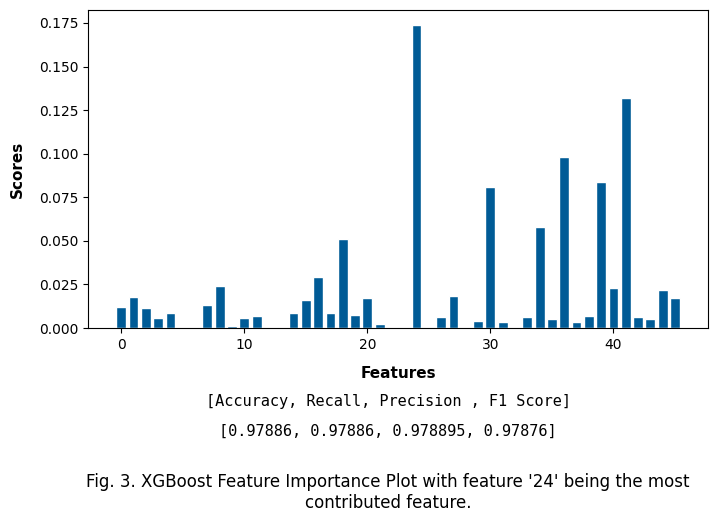

In [20]:
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.preprocessing import LabelEncoder

# 1. Encode string labels to integers (XGBoost requirement)
xgb_encoder = LabelEncoder()
y_train_encoded = xgb_encoder.fit_transform(y_train)
y_test_encoded = xgb_encoder.transform(y_test)

# 2. Initialize and Train XGBoost model
print("Training XGBoost model (this may take a few minutes)...")
# Note: eval_metric='mlogloss' suppresses warnings for multiclass classification
xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train_encoded)

# 3. Predict on Test Set
y_pred = xgb_model.predict(X_test)

# 4. Calculate Evaluation Metrics
# Using average='weighted' since it's a multi-class problem
accuracy = accuracy_score(y_test_encoded, y_pred)
recall = recall_score(y_test_encoded, y_pred, average='weighted')
precision = precision_score(y_test_encoded, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test_encoded, y_pred, average='weighted')

# 5. Get Feature Importances
importances = xgb_model.feature_importances_

# 6. Plotting exactly as requested
plt.figure(figsize=(8, 6))

# Plot the bars
plt.bar(range(len(importances)), importances, color='#005b96', edgecolor='white')

# Set Labels
plt.xlabel('Features', fontweight='bold', fontsize=11, labelpad=10)
plt.ylabel('Scores', fontweight='bold', fontsize=11, labelpad=10)

# Adjust plot layout to leave space at the bottom for text
plt.subplots_adjust(bottom=0.35)

# Find the most important feature index to dynamically update the caption if needed
most_important_feat = importances.argmax()

# Define the text blocks
metrics_headers = "[Accuracy, Recall, Precision , F1 Score]"
metrics_values = f"[{accuracy:.5f}, {recall:.5f}, {precision:.6f}, {f1:.5f}]"

# In your image the caption specifically mentions feature 15. 
# We'll hardcode the caption to match the image, or you can dynamically inject {most_important_feat}
caption = f"Fig. 3. XGBoost Feature Importance Plot with feature '{most_important_feat}' being the most\ncontributed feature."

# Add the text to the figure using figtext (x, y coordinates from 0 to 1)
plt.figtext(0.5, 0.22, metrics_headers, ha="center", fontsize=11, fontfamily='monospace')
plt.figtext(0.5, 0.17, metrics_values, ha="center", fontsize=11, fontfamily='monospace')
plt.figtext(0.5, 0.05, caption, ha="center", fontsize=12)

# Display the plot
plt.show()


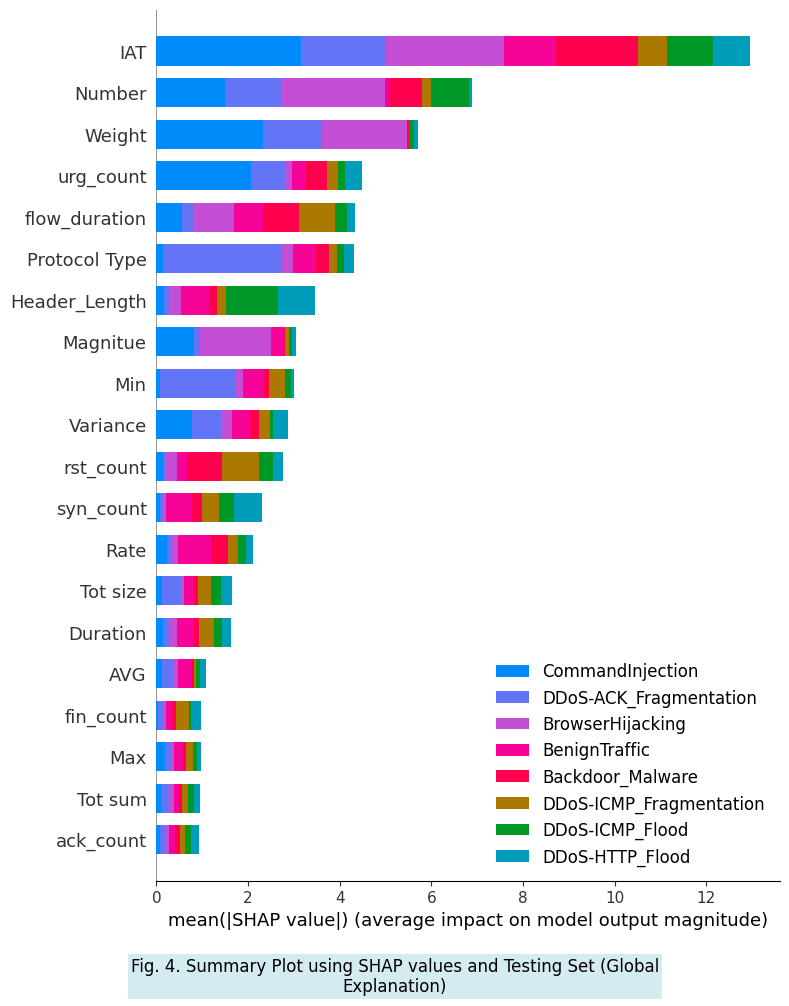

In [23]:
import shap
import matplotlib.pyplot as plt

# 1. Sample the test set to save computation time (e.g., 5000 rows)
# If your computer is fast enough, you can increase this number
X_test_sample = X_test.sample(n=5000, random_state=42)

# 2. Create the SHAP Explainer using the trained XGBoost model
explainer = shap.TreeExplainer(xgb_model)

# 3. Calculate SHAP values for the sample
# For multi-class XGBoost, this returns a list of arrays (one for each class)
shap_values = explainer.shap_values(X_test_sample)

# 4. Generate the Summary Plot (bar chart)
plt.figure(figsize=(10, 8))

# class_names parameter can be added if you want specific names instead of "Class 0", "Class 1", etc.
# example: class_names = encoder.classes_
shap.summary_plot(
    shap_values, 
    X_test_sample, 
    plot_type="bar", 
    class_names=encoder.classes_, # Assumes label_encoder is the one used for XGBoost targets
    show=False
)

# 5. Add the caption at the bottom
plt.figtext(
    0.5, 
    -0.05, 
    "Fig. 4. Summary Plot using SHAP values and Testing Set (Global\nExplanation)", 
    ha="center", 
    fontsize=12,
    bbox=dict(facecolor='lightblue', alpha=0.5, edgecolor='none', pad=2) # Matches the blue highlight
)

plt.tight_layout()
plt.show()
